### Pipeline context

This notebook is part of the protein design pipeline:

Structure → Design → Validation → Ranking → Optimization1m

# 03 Design Analysis

## Goal
Analyze sequences generated by ProteinMPNN.

## Purpose
- load generated sequence files
- compare designs with the reference sequence
- count mutations
- inspect early design diversity


***Load generated sequences***

In [14]:
from pathlib import Path
import pandas as pd

seq_file = Path("../results/design_sequences/seqs/1LYZ_clean_protein_only.fa")

sequences = []

with open(seq_file) as f:
    lines = f.readlines()

for i in range(0, len(lines), 2):
    sequences.append({
        "name": lines[i].strip(),
        "sequence": lines[i+1].strip()
    })

design_df = pd.DataFrame(sequences)
design_df

,name,sequence
0,">1LYZ_clean_protein_only, score=1.6112, global...",KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...
1,">T=0.1, sample=1, score=0.8716, global_score=0...",MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...
2,">T=0.1, sample=2, score=0.8667, global_score=0...",KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...
3,">T=0.1, sample=3, score=0.9082, global_score=0...",MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...
4,">T=0.1, sample=4, score=0.8506, global_score=0...",KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...
5,">T=0.1, sample=5, score=0.8566, global_score=0...",MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...


***Add reference sequence***

In [15]:
reference_seq = open("../data/processed/1LYZ_chain_A_sequence.txt").read().strip()

print("Reference length:", len(reference_seq))

Reference length: 129


***Compute mutation count***

In [16]:
def mutation_count(seq):
    return sum(a != b for a, b in zip(seq, reference_seq))

design_df["num_mutations"] = design_df["sequence"].apply(mutation_count)
design_df

,name,sequence,num_mutations
0,">1LYZ_clean_protein_only, score=1.6112, global...",KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...,0
1,">T=0.1, sample=1, score=0.8716, global_score=0...",MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...,70
2,">T=0.1, sample=2, score=0.8667, global_score=0...",KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...,73
3,">T=0.1, sample=3, score=0.9082, global_score=0...",MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...,76
4,">T=0.1, sample=4, score=0.8506, global_score=0...",KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...,70
5,">T=0.1, sample=5, score=0.8566, global_score=0...",MKFSRCGLAQELKKLGMDNFNGYPLGAWVCLAEVTAGGDTSVSRAY...,67


***Compute mutation positions (IMPORTANT)***

In [17]:
def mutation_positions(seq):
    return [i+1 for i, (a, b) in enumerate(zip(seq, reference_seq)) if a != b]

design_df["mutation_positions"] = design_df["sequence"].apply(mutation_positions)
design_df.head()

,name,sequence,num_mutations,mutation_positions
0,">1LYZ_clean_protein_only, score=1.6112, global...",KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...,0,[]
1,">T=0.1, sample=1, score=0.8716, global_score=0...",MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...,70,"[1, 2, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ..."
2,">T=0.1, sample=2, score=0.8667, global_score=0...",KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...,73,"[2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21, 2..."
3,">T=0.1, sample=3, score=0.9082, global_score=0...",MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...,76,"[1, 2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21..."
4,">T=0.1, sample=4, score=0.8506, global_score=0...",KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...,70,"[2, 3, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ..."


***Compute mutation strings***

In [18]:
def mutation_strings(seq):
    muts = []
    for i, (wt, mut) in enumerate(zip(reference_seq, seq)):
        if wt != mut:
            muts.append(f"{wt}{i+1}{mut}")
    return ";".join(muts)

design_df["mutations"] = design_df["sequence"].apply(mutation_strings)
design_df.head()

,name,sequence,num_mutations,mutation_positions,mutations
0,">1LYZ_clean_protein_only, score=1.6112, global...",KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRN...,0,[],
1,">T=0.1, sample=1, score=0.8716, global_score=0...",MKFSRCELARRLKELGMDNLFGYPLGAYVCLAEVTGGGDTSVTRKD...,70,"[1, 2, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...",K1M;V2K;G4S;A10R;A11R;M12L;R14E;H15L;L17M;Y20L...
2,">T=0.1, sample=2, score=0.8667, global_score=0...",KKYTRCGLAKELKKLGMDNFNGYPLGYWVCLAWYTAGGDNSKTEKL...,73,"[2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21, 2...",V2K;F3Y;G4T;E7G;A10K;A11E;M12L;R14K;H15L;L17M;...
3,">T=0.1, sample=3, score=0.9082, global_score=0...",MKYSRCGLAQELKKLGMDNFNGYPLGAYVCLAMVSAGGDNSVSKAD...,76,"[1, 2, 3, 4, 7, 10, 11, 12, 14, 15, 17, 20, 21...",K1M;V2K;F3Y;G4S;E7G;A10Q;A11E;M12L;R14K;H15L;L...
4,">T=0.1, sample=4, score=0.8506, global_score=0...",KKYSRCELAQTLKKLGMDNFNGYPLGAFVCLAWYTAGGDSSVSRKD...,70,"[2, 3, 4, 10, 11, 12, 14, 15, 17, 20, 21, 24, ...",V2K;F3Y;G4S;A10Q;A11T;M12L;R14K;H15L;L17M;Y20F...


***Inspect mutation distribution***

In [19]:
design_df["num_mutations"].describe()

count     6.000000
mean     59.333333
std      29.227841
min       0.000000
25%      67.750000
50%      70.000000
75%      72.250000
max      76.000000
Name: num_mutations, dtype: float64

***Visualize mutation counts***

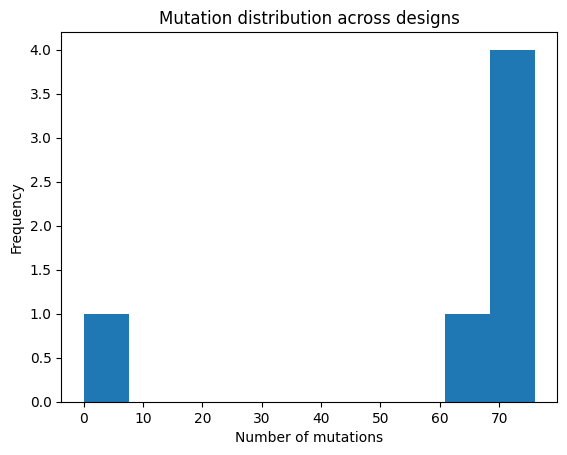

In [20]:
import matplotlib.pyplot as plt

design_df["num_mutations"].plot(kind="hist", bins=10)
plt.xlabel("Number of mutations")
plt.title("Mutation distribution across designs")
plt.show()

***Inspect one design vs reference***

In [21]:
print("Reference:", reference_seq[:60])
print("Design   :", design_df.iloc[0]["sequence"][:60])
print("Mutations:", design_df.iloc[0]["mutations"])

Reference: KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINS
Design   : KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINS
Mutations: 


***Save analysis table***

In [22]:
output_path = Path("../results/tables/design_candidates.csv")
design_df.to_csv(output_path, index=False)

print("Saved design analysis to:", output_path)

Saved design analysis to: ../results/tables/design_candidates.csv


## Design Sequence Analysis

The generated sequences were compared to the reference sequence to quantify mutation patterns.

### Key observations
- mutation counts vary across designs
- mutations are distributed across the sequence
- designs represent structurally compatible sequence alternatives

### Why this matters
This step converts raw sequence outputs into interpretable mutation-level information, enabling downstream filtering and ranking.

### Important limitation
Mutation counts and positions do not directly indicate stability, function, or experimental success.

In [24]:
# Run locally if needed
with open("../results/design_sequences/seqs/1LYZ_clean_protein_only.fa") as f:
    lines = f.readlines()

cleaned = []
for i in range(0, len(lines), 2):
    cleaned.append(f">seq_{i//2}\n")
    cleaned.append(lines[i+1])

with open("../results/design_sequences/seqs/clean_input.fa", "w") as f:
    f.writelines(cleaned)

print("Clean FASTA ready")

Clean FASTA ready
